# Assignment - Analyzing the IMDB Top 1000 Movies

In the next few assignments, you will be working with this data set of IMDB top 1000 movies.

Source: https://www.kaggle.com/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

In [13]:
import pandas as pd
import numpy as np

In [15]:
# Read the data file "imdb_top_1000.csv" to a dataframe named "imdb"
imdb = pd.read_csv('https://raw.githubusercontent.com/jiexunli-wwu/mis433/refs/heads/main/data/imdb_top_1000.csv', header=0)
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [16]:
# Describe the dataframe using the info() method.
imdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB


In [21]:
# List all the column names:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross',
       'Runtime_min'],
      dtype='object')

## Part 1: Data Manipulation

Redo the following to clean the data.

In [22]:
# Count the number of movies in each "Released_Year"?
# Hint: value_counts()
imdb['Released_Year'].value_counts()

,count
Released_Year,
2014,32
2004,31
2009,29
2013,28
2016,28
...,...
1920,1
1930,1
1922,1


In [23]:
# In this dataset, there is a movie with an error in "Released_Year".
# Hint: Released_Year should be a 4-digit integer but this movie's is not.
# Find this movie.
imdb[imdb['Released_Year'] == 'PG']

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross,Runtime_min
966,https://m.media-amazon.com/images/M/MV5BNjEzYj...,Apollo 13,PG,U,140 min,"Adventure, Drama, History",7.6,NASA must devise a strategy to return Apollo 1...,77.0,Ron Howard,Tom Hanks,Bill Paxton,Kevin Bacon,Gary Sinise,269197,"173,837,933",140


In [24]:
# Correct the values for the corresponding columns ("Release_Year" and "Certificate").
# You may want to look up this movie on www.imdb.com.
# Hint: You can set value for a particular set by: df.loc[row_name, column_name] = new_value

# Find the index of the movie with Released_Year 'PG'
idx = imdb[imdb['Released_Year'] == 'PG'].index[0]

# Correct Released_Year and Certificate based on IMDB data for Apollo 13
imdb.loc[idx, 'Released_Year'] = '1995'
imdb.loc[idx, 'Certificate'] = 'PG'

# Display the corrected row to verify
display(imdb.loc[idx])

,966
Poster_Link,https://m.media-amazon.com/images/M/MV5BNjEzYj...
Series_Title,Apollo 13
Released_Year,1995
Certificate,PG
Runtime,140 min
Genre,"Adventure, Drama, History"
IMDB_Rating,7.6
Overview,NASA must devise a strategy to return Apollo 1...
Meta_score,77.0
Director,Ron Howard


In [25]:
# Change the data type of "Released_Year" to int
imdb['Released_Year'] = imdb['Released_Year'].astype(int)

In [26]:
# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
filtered_movies = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
display(filtered_movies[['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False))

,Series_Title,Released_Year,Certificate,Gross
19,Gisaengchung,2019,A,"53,367,844"
33,Joker,2019,A,"335,451,311"
8,Inception,2010,UA,"292,576,195"
21,Interstellar,2014,UA,"188,020,017"
35,The Intouchables,2011,UA,"13,182,281"
34,Whiplash,2014,A,"13,092,000"
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [27]:
# Does the sorting result looks right to you? What's the problem?
# The sorting result does not look right because "Gross" is currently an object (string) type,
# not a numeric type. Therefore, it is sorting alphabetically rather than numerically.
# To fix this, "Gross" needs to be converted to a numeric data type (e.g., float)
# after removing non-numeric characters like commas.

In [28]:
# Resolve this problem of "Gross" and convert its data type to float
# Hint: You may find this webpage useful:
# https://stackoverflow.com/questions/28986489/how-to-replace-text-in-a-column-of-a-pandas-dataframe

# Remove commas from the 'Gross' column and convert to numeric, coercing errors to NaN
imdb['Gross'] = imdb['Gross'].str.replace(',', '', regex=False).astype(float)

In [29]:
# Next, redo the sorting on Gross

# Select all movies released after (>=) 2010 and with IMDB_Rating>=8.5
# Show their title, released year, Certificate, and gross.
# Sort them in descending order of "Gross"
filtered_movies_corrected_gross = imdb[(imdb['Released_Year'] >= 2010) & (imdb['IMDB_Rating'] >= 8.5)]
display(filtered_movies_corrected_gross[['Series_Title', 'Released_Year', 'Certificate', 'Gross']].sort_values(by='Gross', ascending=False))

,Series_Title,Released_Year,Certificate,Gross
33,Joker,2019,A,335451311.0
8,Inception,2010,UA,292576195.0
21,Interstellar,2014,UA,188020017.0
19,Gisaengchung,2019,A,53367844.0
35,The Intouchables,2011,UA,13182281.0
34,Whiplash,2014,A,13092000.0
18,Hamilton,2020,PG-13,NaN
20,Soorarai Pottru,2020,U,NaN


In [19]:
# Add a new column "Runtime_min" by removing the substring ' min" in "Runtime"
# Set its data type as int
# Hint: https://stackoverflow.com/questions/36505847/substring-of-an-entire-column-in-pandas-dataframe
imdb['Runtime_min'] = imdb['Runtime'].str.replace(' min', '', regex=False).astype(int)

In [30]:
# Add a new column "Age_Year" by expression: [current year] - Released_Year
import datetime
current_year = datetime.datetime.now().year
imdb['Age_Year'] = current_year - imdb['Released_Year']

In [31]:
# Add a new column "Decade" with values as 1980, 1990, 2000, 2010, 2020, etc.
imdb['Decade'] = (imdb['Released_Year'] // 10) * 10

## Part 2: Data Summarization

Done!

## Part 3: Data Visualization

Finish Parts 1 and 2 (data manipulation and summarization) before you work through this section.

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

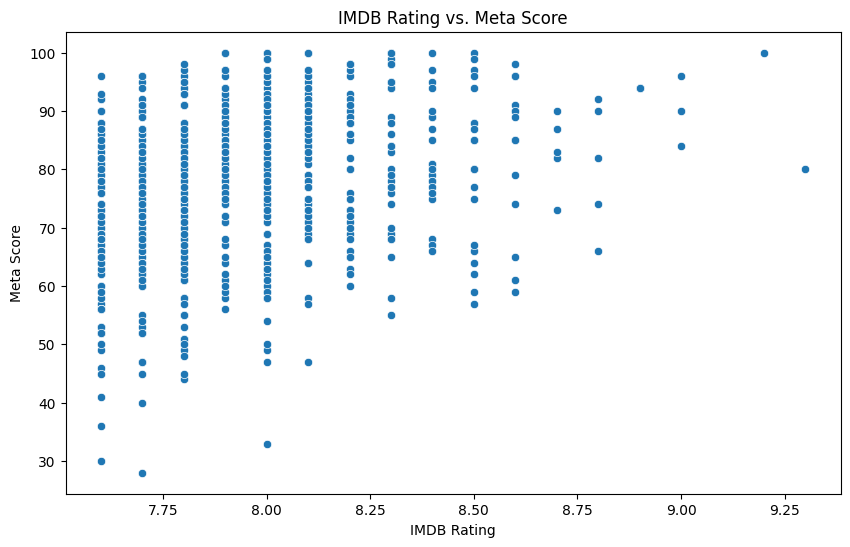

In [32]:
# Create a scatterplot of the two scores, "IMDB_Rating" and "Meta_score".
# In a sentence or two, describe what this pair of scores suggests about the movies.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IMDB_Rating', y='Meta_score', data=imdb)
plt.title('IMDB Rating vs. Meta Score')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.show()

# Description: This scatterplot shows the relationship between IMDB_Rating (user reviews) and Meta_score (critic reviews).
# A general positive correlation can be observed, suggesting that movies liked by critics are often liked by the audience, and vice versa.

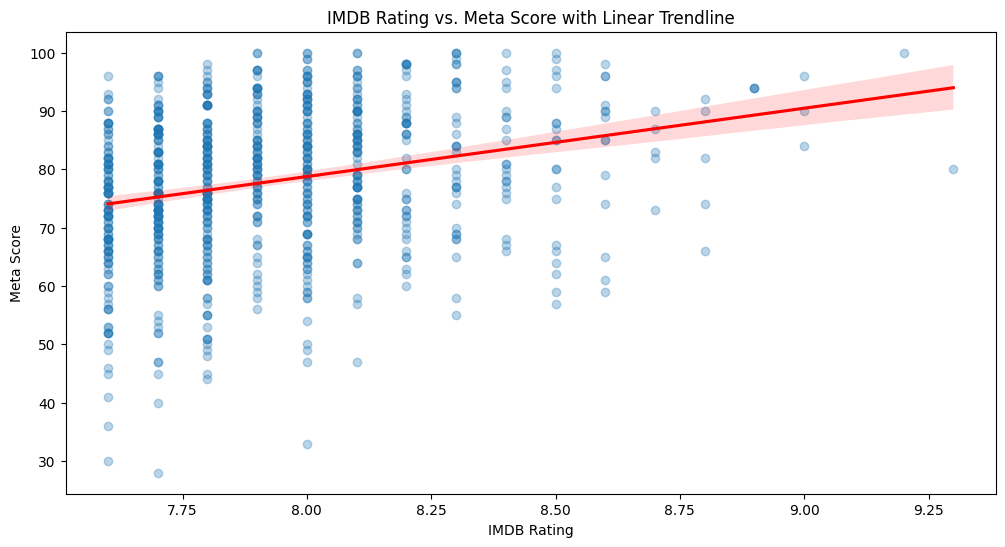

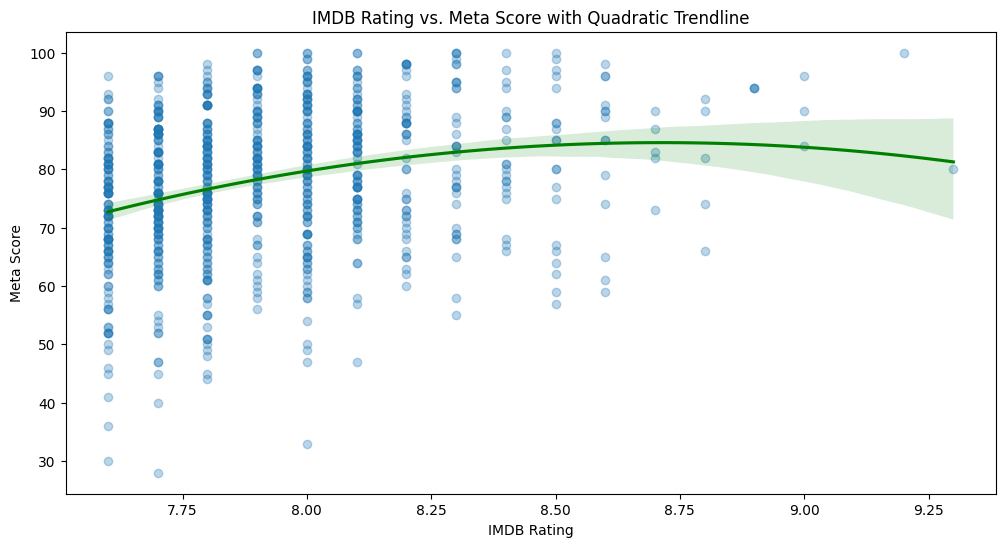

In [33]:
# Fit a trendline to show the relationship between the two scores.
# Hint: sns.regplot()
# Try a few values of the `order` argument (polynomial degree) for the trendline.

plt.figure(figsize=(12, 6))
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, order=1)
plt.title('IMDB Rating vs. Meta Score with Linear Trendline')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.show()

plt.figure(figsize=(12, 6))
sns.regplot(x='IMDB_Rating', y='Meta_score', data=imdb, scatter_kws={'alpha':0.3}, line_kws={'color':'green'}, order=2)
plt.title('IMDB Rating vs. Meta Score with Quadratic Trendline')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.show()

# The trendlines show a positive correlation, with a slight curve suggesting that the relationship might not be perfectly linear,
# but a linear approximation still captures the general trend.

In [34]:
# Do any data points in the scatterplot surprise you?
# Try to identify a few such movies.

# To identify surprising movies, we can look for outliers where IMDB_Rating and Meta_score diverge significantly.
# For example, movies with a very high IMDB_Rating but a relatively low Meta_score, or vice versa.

# Example 1: High IMDB_Rating, relatively low Meta_score
# This might indicate a movie that is a cult classic or appeals strongly to a niche audience,
# but critics were less impressed.
surprising_movies_high_imdb_low_meta = imdb[(imdb['IMDB_Rating'] > 8.5) & (imdb['Meta_score'] < 70)].sort_values(by=['IMDB_Rating', 'Meta_score'], ascending=[False, True])
print("Movies with High IMDB Rating and Relatively Low Meta Score:")
display(surprising_movies_high_imdb_low_meta[['Series_Title', 'IMDB_Rating', 'Meta_score']].head())

# Example 2: Low IMDB_Rating, relatively high Meta_score (less likely in this top 1000 dataset, but possible)
# This might indicate a movie appreciated by critics but not by the broader audience.
surprising_movies_low_imdb_high_meta = imdb[(imdb['IMDB_Rating'] < 7.5) & (imdb['Meta_score'] > 85)].sort_values(by=['IMDB_Rating', 'Meta_score'], ascending=[True, False])
print("\nMovies with Relatively Low IMDB Rating and High Meta Score:")
display(surprising_movies_low_imdb_high_meta[['Series_Title', 'IMDB_Rating', 'Meta_score']].head())

# Looking at the first example, movies like 'The Usual Suspects' or 'Once Upon a Time in America'
# have very high IMDB ratings but their Meta scores, while good, are not proportionally as high,
# suggesting a greater fan appreciation than critical acclaim relative to other highly-rated films.

Movies with High IMDB Rating and Relatively Low Meta Score:


,Series_Title,IMDB_Rating,Meta_score
9,Fight Club,8.8,66.0
26,La vita è bella,8.6,59.0
25,The Green Mile,8.6,61.0
27,Se7en,8.6,65.0



Movies with Relatively Low IMDB Rating and High Meta Score:


,Series_Title,IMDB_Rating,Meta_score


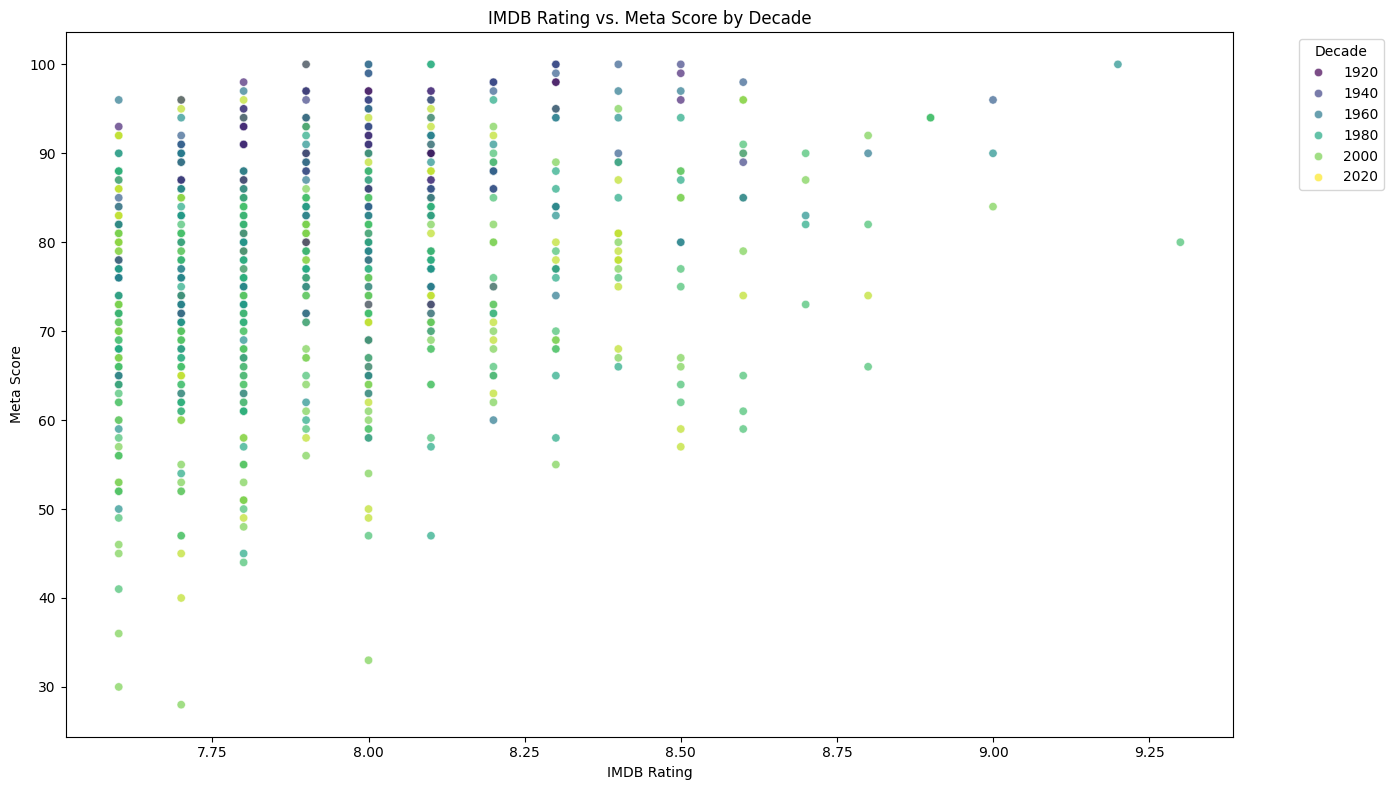

In [35]:
# In the scatterplot, use color to distinguish movies from different decades.

plt.figure(figsize=(14, 8))
sns.scatterplot(x='IMDB_Rating', y='Meta_score', hue='Decade', data=imdb, palette='viridis', alpha=0.7)
plt.title('IMDB Rating vs. Meta Score by Decade')
plt.xlabel('IMDB Rating')
plt.ylabel('Meta Score')
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3466/718353283.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=movies_per_decade.index, y=movies_per_decade.values, palette='plasma')


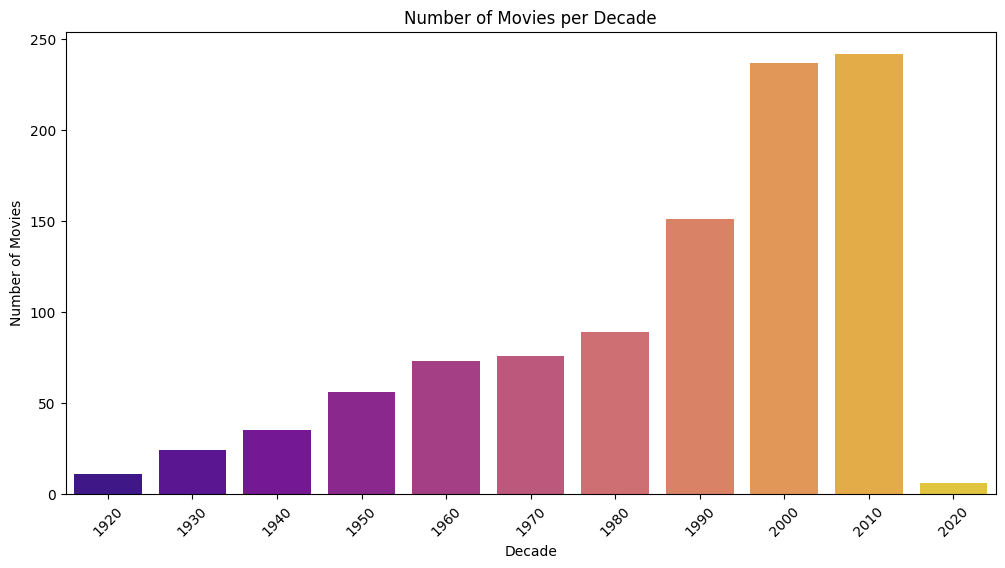

In [36]:
# Create a chart that shows how many movies fall in each decade.

movies_per_decade = imdb['Decade'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=movies_per_decade.index, y=movies_per_decade.values, palette='plasma')
plt.title('Number of Movies per Decade')
plt.xlabel('Decade')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45)
plt.show()

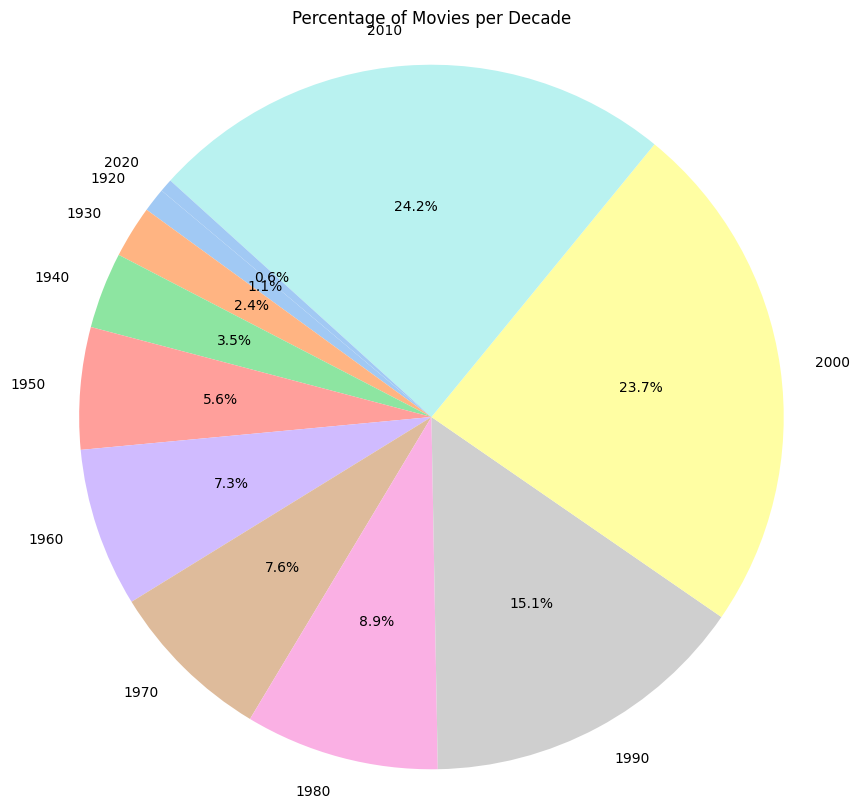

In [37]:
# Create a chart that shows the percentage of movies in each decade.

movies_per_decade_percentage = (imdb['Decade'].value_counts(normalize=True) * 100).sort_index()

plt.figure(figsize=(10, 10))
plt.pie(movies_per_decade_percentage.values, labels=movies_per_decade_percentage.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Percentage of Movies per Decade')
plt.axis('equal')
plt.show()

/tmp/ipykernel_3466/1113836600.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.index, y=top_directors.values, palette='mako')


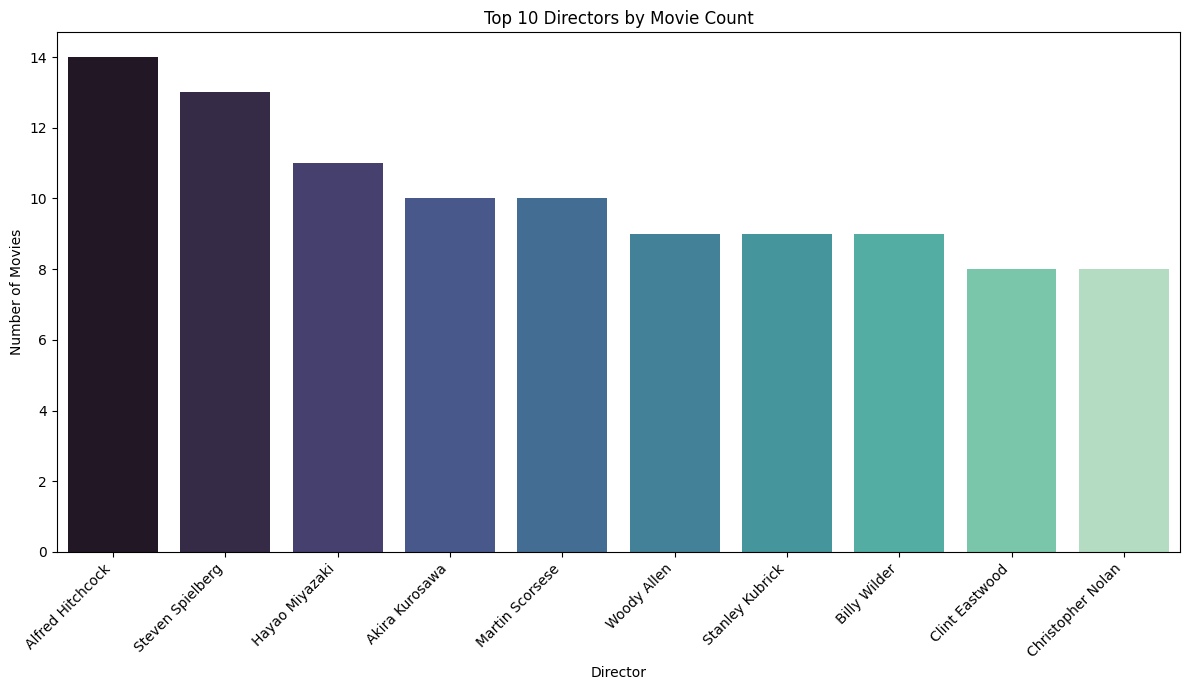

In [38]:
# Count movies by director.
# Show the top 10 directors by movie count in a bar chart.

top_directors = imdb['Director'].value_counts().head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_directors.index, y=top_directors.values, palette='mako')
plt.title('Top 10 Directors by Movie Count')
plt.xlabel('Director')
plt.ylabel('Number of Movies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

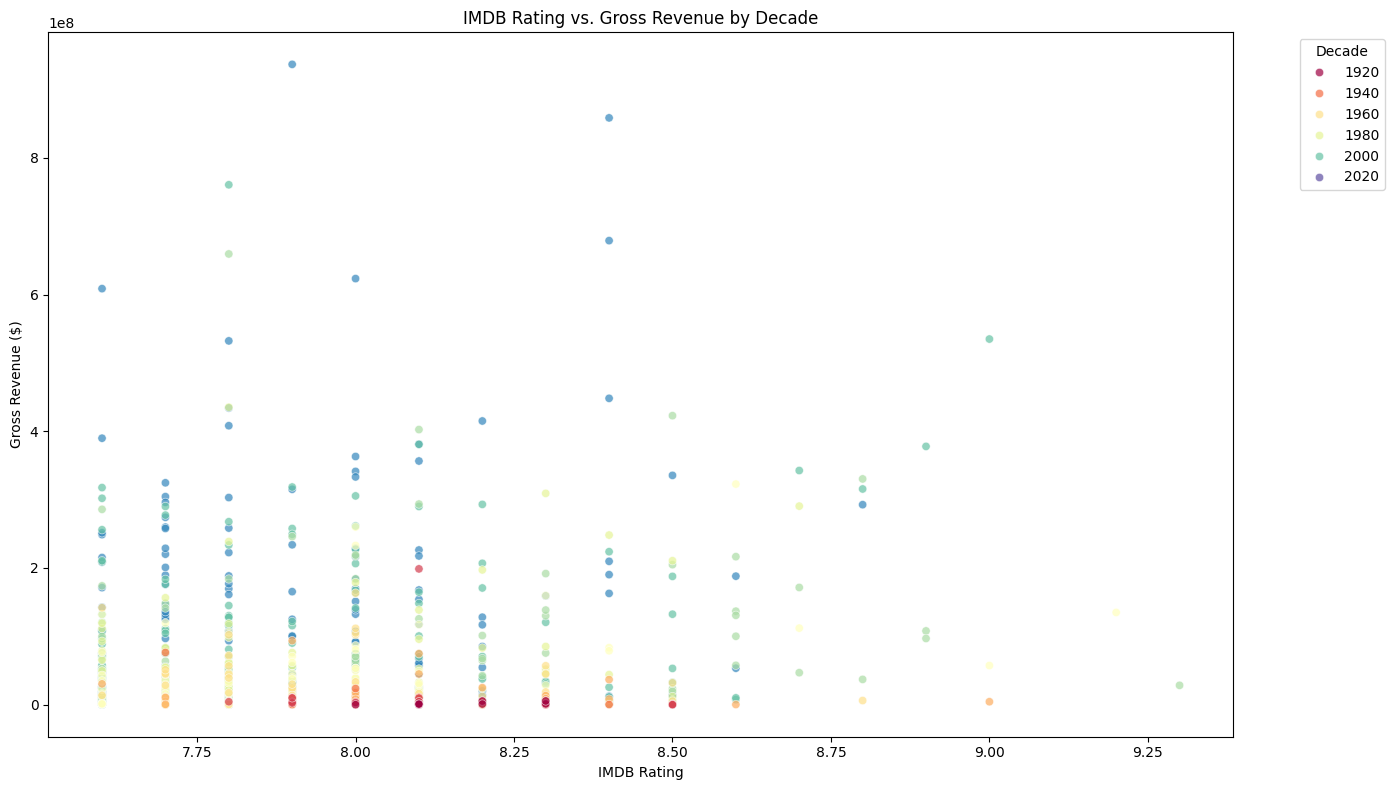

In [39]:
# Create a scatterplot of "IMDB_Rating" and "Gross".
# Use color to distinguish movies from different decades.
# Briefly interpret what the chart shows.

plt.figure(figsize=(14, 8))
sns.scatterplot(x='IMDB_Rating', y='Gross', hue='Decade', data=imdb, palette='Spectral', alpha=0.7)
plt.title('IMDB Rating vs. Gross Revenue by Decade')
plt.xlabel('IMDB Rating')
plt.ylabel('Gross Revenue ($)')
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Interpretation: The chart suggests that there isn't a strong linear relationship between IMDB Rating and Gross Revenue.
# Many highly-rated movies don't necessarily have the highest gross, and some movies with slightly lower (but still high)
# IMDB ratings can achieve very high gross revenues. Movies from more recent decades (e.g., 2000s, 2010s) tend to
# occupy the higher gross revenue ranges, which is expected due to inflation and the growth of the movie market.

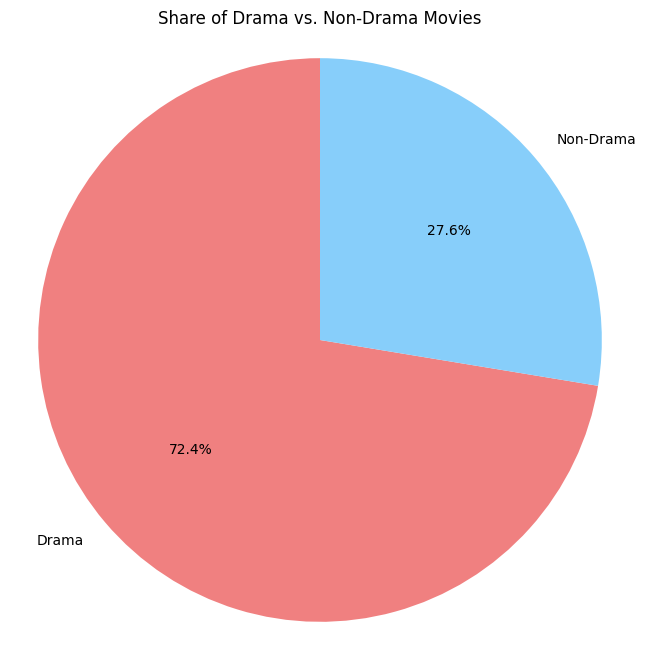

In [40]:
# Create a column named "Drama" that indicates whether a movie's genres include "Drama".
# Create a pie chart showing the share of drama vs. non-drama movies.

imdb['Is_Drama'] = imdb['Genre'].apply(lambda x: 'Drama' in x.split(', '))

drama_counts = imdb['Is_Drama'].value_counts()
drama_labels = ['Drama' if x else 'Non-Drama' for x in drama_counts.index]

plt.figure(figsize=(8, 8))
plt.pie(drama_counts.values, labels=drama_labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightskyblue'])
plt.title('Share of Drama vs. Non-Drama Movies')
plt.axis('equal')
plt.show()

/tmp/ipykernel_3466/1164725645.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gross_by_decade.index, y=gross_by_decade.values, palette='cubehelix')


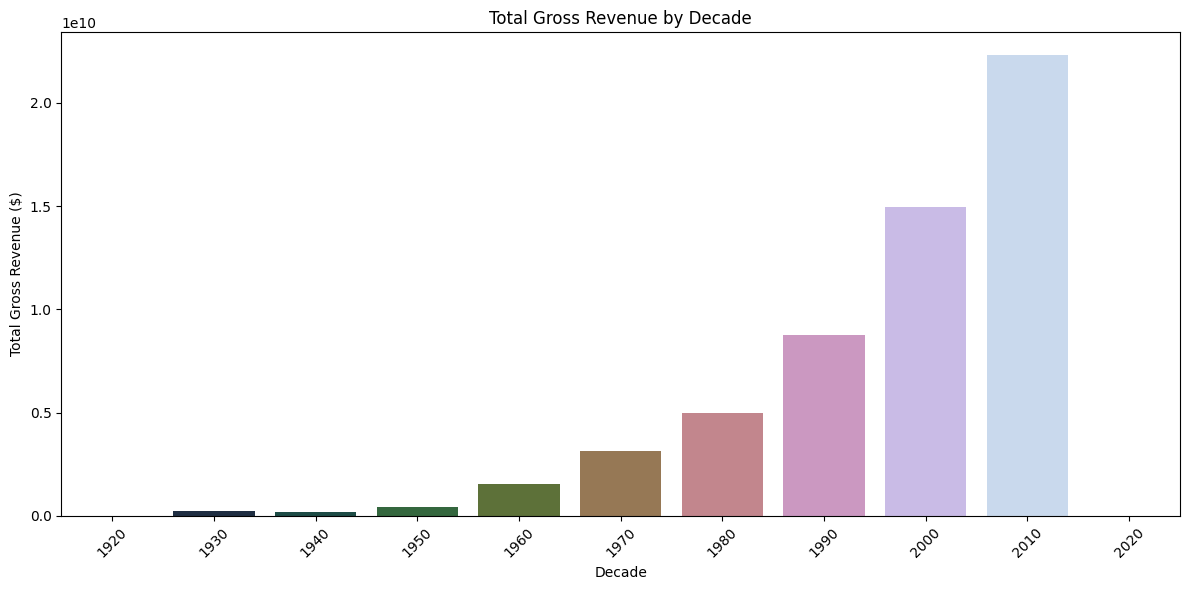

In [41]:
# Create a plot comparing gross revenue across decades.

# Group by Decade and calculate the sum of Gross, dropping NaNs first
gross_by_decade = imdb.groupby('Decade')['Gross'].sum().dropna()

plt.figure(figsize=(12, 6))
sns.barplot(x=gross_by_decade.index, y=gross_by_decade.values, palette='cubehelix')
plt.title('Total Gross Revenue by Decade')
plt.xlabel('Decade')
plt.ylabel('Total Gross Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

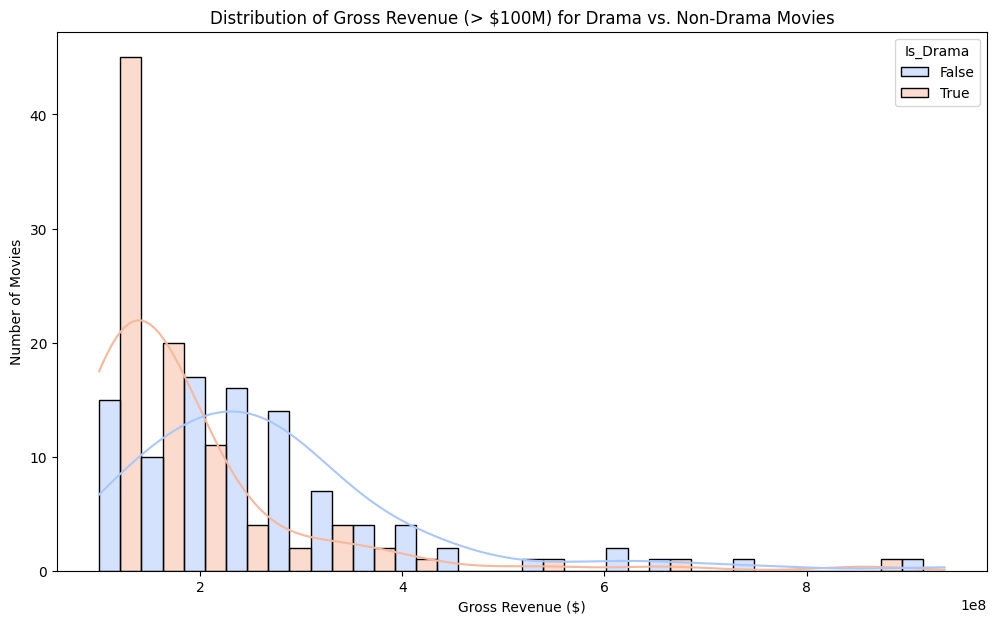

In [42]:
# For movies with gross over $100 million:
# Create a histogram of gross for drama vs. non-drama movies.

movies_over_100M = imdb[imdb['Gross'] > 100_000_000].dropna(subset=['Gross'])

plt.figure(figsize=(12, 7))
sns.histplot(data=movies_over_100M, x='Gross', hue='Is_Drama', multiple='dodge', bins=20, kde=True, palette='coolwarm')
plt.title('Distribution of Gross Revenue (> $100M) for Drama vs. Non-Drama Movies')
plt.xlabel('Gross Revenue ($)')
plt.ylabel('Number of Movies')
plt.show()

Text(0, 0.5, 'Number of Movies')

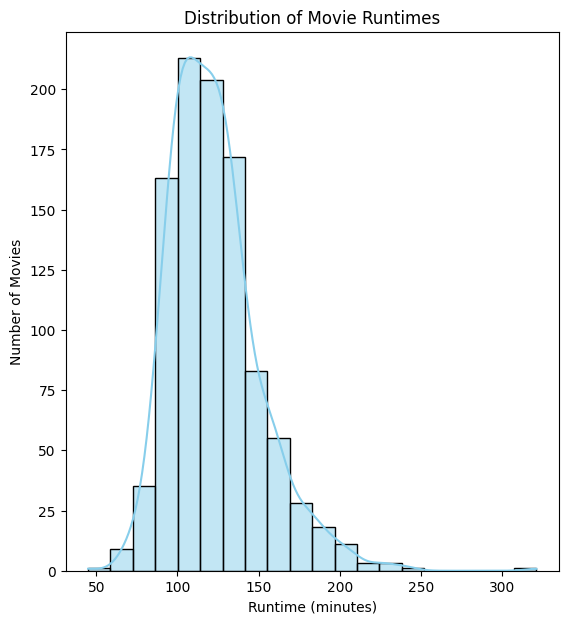

In [43]:
# Come up with two more questions about this dataset. Create one chart or figure for each.
# Question 1: What is the distribution of movie runtimes?

plt.figure(figsize=(14, 7))
plt.subplot(1, 2, 1)
sns.histplot(imdb['Runtime_min'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Movie Runtimes')
plt.xlabel('Runtime (minutes)')
plt.ylabel('Number of Movies')



# Interpretation: The plot shows that most movies are between 90 and 150 minutes.


/tmp/ipykernel_3466/1827770937.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_runtime_by_decade.index, y=avg_runtime_by_decade.values, palette='viridis')


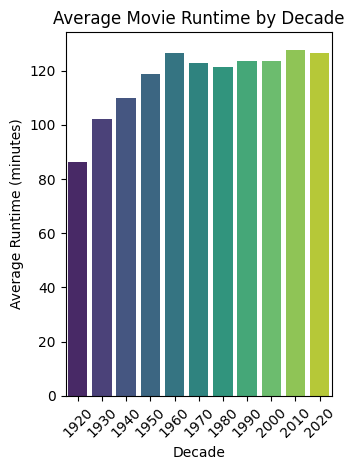

In [44]:
# Question 2: Are there any differences in average runtime across decades?

plt.subplot(1, 2, 2)
avg_runtime_by_decade = imdb.groupby('Decade')['Runtime_min'].mean()
sns.barplot(x=avg_runtime_by_decade.index, y=avg_runtime_by_decade.values, palette='viridis')
plt.title('Average Movie Runtime by Decade')
plt.xlabel('Decade')
plt.ylabel('Average Runtime (minutes)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# The plot suggests that average movie runtimes have generally increased over the decades,
# with a peak around the 1970s-1980s and again in more recent decades compared to older films.